# Production-Grade Ensemble CNN Classifier with Performance Benchmarks

In [1]:
!python -m pip install --upgrade pip

In [2]:
import sys
print(sys.executable)

c:\Users\nidhi\AppData\Local\Programs\Python\Python310\python.exe


In [4]:
import sys
!{sys.executable} -m pip install tensorflow

  Using cached tensorflow-2.21.0-cp310-cp310-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.3.0-cp310-cp310-win_amd64.whl.metadata (7.6 kB)
  Using cached keras-3.12.4-py3-none-any.whl.metadata (6.0 kB)
  Using cached h5py-3.14.0-cp310-cp310-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.6.0-cp310-cp310-win_amd64.whl.metadata (8.8 kB)
  Using cached wheel-0.48.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached rich-15.0.0-p

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.0 which is incompatible.
google-api-core 2.30.0 requires protobuf<7.0.0,>=4.25.8, but you have protobuf 7.36.0 which is incompatible.
google-cloud-firestore 2.25.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.36.0 which is incompatible.
googleapis-common-protos 1.73.0 requires protobuf!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.36.0 which is incompatible.
proto-plus 1.27.1 requires protobuf<7.0.0,>=3.19.0, but you have protobuf 7.36.0 which is incompatible.
streamlit 1.52.2 requires protobuf<7,>=3.20, but you have protobuf 7.36.0 which is incompatible.


In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("TensorFlow version:", tf.__version__)

c:\Users\nidhi\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


TensorFlow version: 2.21.0


In [2]:

dataset_path = Path(r"C:\Users\nidhi\Downloads\casting_split")

image_size = (224, 224)
batch_size = 32

class_names = ["ok_front", "def_front"]

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path / "train",
    class_names=class_names,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path / "validation",
    class_names=class_names,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path / "test",
    class_names=class_names,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary",
    shuffle=False
)

print("Classes:", class_names)

Found 909 files belonging to 2 classes.
Found 195 files belonging to 2 classes.
Found 196 files belonging to 2 classes.
Classes: ['ok_front', 'def_front']


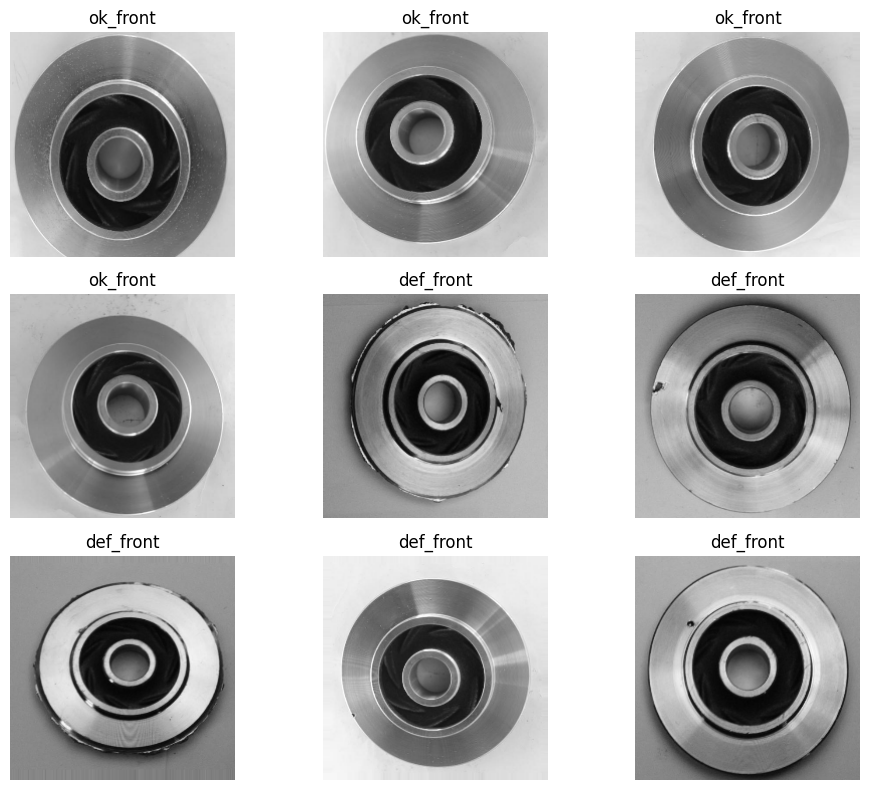

In [3]:
plt.figure(figsize=(10, 8))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i].numpy()[0])])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.10)
])

print("Data augmentation ready!")

Data augmentation ready!


In [5]:
cnn1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),

    data_augmentation,
    tf.keras.layers.Rescaling(1.0 / 255),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

cnn1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
cnn1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

callbacks_cnn1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "cnn1_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history_cnn1 = cnn1.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15,
    callbacks=callbacks_cnn1
)

Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 633ms/step - accuracy: 0.7019 - loss: 0.5902 - precision: 0.7068 - recall: 0.8608 - val_accuracy: 0.6872 - val_loss: 0.6404 - val_precision: 0.6628 - val_recall: 0.9744
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 586ms/step - accuracy: 0.7008 - loss: 0.5771 - precision: 0.7338 - recall: 0.7875 - val_accuracy: 0.6256 - val_loss: 0.7890 - val_precision: 0.6158 - val_recall: 1.0000
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 626ms/step - accuracy: 0.7162 - loss: 0.5698 - precision: 0.7491 - recall: 0.7930 - val_accuracy: 0.6308 - val_loss: 0.7555 - val_precision: 0.6203 - val_recall: 0.9915
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 613ms/step - accuracy: 0.6755 - loss: 0.5945 - precision: 0.7131 - recall: 0.7692 - val_accuracy: 0.6051 - val_loss: 0.8624 - val_precision: 0.6031 - val_recall: 1.0000
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 609ms/step - accuracy: 0.7118 - loss: 0.5702 - precision: 0.7448 - recall: 0.7912 - val_accuracy: 0.6205 - val_los

In [8]:
test_results_cnn1 = cnn1.evaluate(
    test_dataset,
    verbose=1
)

print("\nCNN 1 Test Results:")
print("Loss:", test_results_cnn1[0])
print("Accuracy:", test_results_cnn1[1])
print("Precision:", test_results_cnn1[2])
print("Recall:", test_results_cnn1[3])

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.6939 - loss: 0.5569 - precision: 0.7458 - recall: 0.7458    

CNN 1 Test Results:
Loss: 0.5569308400154114
Accuracy: 0.6938775777816772
Precision: 0.7457627058029175
Recall: 0.7457627058029175


CNN 1 Classification Report:

              precision    recall  f1-score   support

    ok_front     0.6154    0.6154    0.6154        78
   def_front     0.7458    0.7458    0.7458       118

    accuracy                         0.6939       196
   macro avg     0.6806    0.6806    0.6806       196
weighted avg     0.6939    0.6939    0.6939       196


Confusion Matrix:
[[48 30]
 [30 88]]


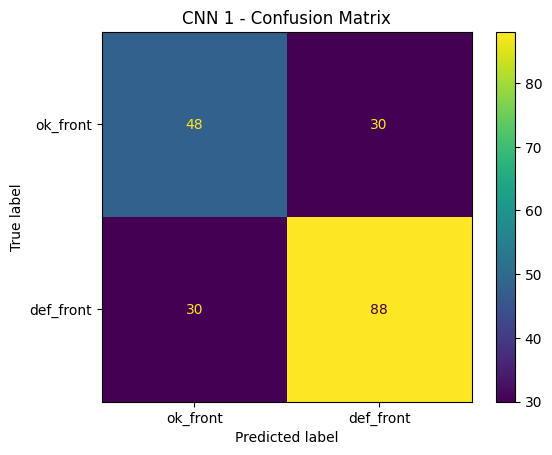

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# True labels
y_true = np.concatenate([
    labels.numpy().flatten()
    for _, labels in test_dataset
])

# Predictions
y_prob = cnn1.predict(test_dataset, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

# Classification Report
print("CNN 1 Classification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()
plt.title("CNN 1 - Confusion Matrix")
plt.show()

In [10]:
cnn2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),

    data_augmentation,
    tf.keras.layers.Rescaling(1.0 / 255),

    tf.keras.layers.Conv2D(32, (3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.30),

    tf.keras.layers.Conv2D(128, (3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.35),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.40),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

cnn2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,465 (400.25 KB)

 Trainable params: 102,017 (398.50 KB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
cnn2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

callbacks_cnn2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "cnn2_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history_cnn2 = cnn2.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15,
    callbacks=callbacks_cnn2
)

Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.6832 - loss: 0.5915 - precision: 0.7108 - recall: 0.7967 - val_accuracy: 0.4000 - val_loss: 0.8930 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.7426 - loss: 0.5294 - precision: 0.7900 - recall: 0.7784 - val_accuracy: 0.4000 - val_loss: 0.8006 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.7646 - loss: 0.4955 - precision: 0.8051 - recall: 0.8022 - val_accuracy: 0.6769 - val_loss: 0.6193 - val_precision: 0.6849 - val_recall: 0.8547
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.7844 - loss: 0.4762 - precision: 0.8289 - recall: 0.8077 - val_accuracy: 0.6000 - val_loss: 0.6627 - val_precision: 0.6000 - val_recall: 1.0000
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.7811 - loss: 0.4773 - precision: 0.8382 - recall: 0.7875 - val_accuracy: 0.6103 - val_lo

In [12]:
test_results_cnn2 = cnn2.evaluate(
    test_dataset,
    verbose=1
)

print("\nCNN 2 Test Results:")
print("Loss:", test_results_cnn2[0])
print("Accuracy:", test_results_cnn2[1])
print("Precision:", test_results_cnn2[2])
print("Recall:", test_results_cnn2[3])

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 213ms/step - accuracy: 0.6837 - loss: 0.5668 - precision: 0.7059 - recall: 0.8136    

CNN 2 Test Results:
Loss: 0.5667769312858582
Accuracy: 0.6836734414100647
Precision: 0.7058823704719543
Recall: 0.8135592937469482


CNN 2 Classification Report:

              precision    recall  f1-score   support

    ok_front     0.6333    0.4872    0.5507        78
   def_front     0.7059    0.8136    0.7559       118

    accuracy                         0.6837       196
   macro avg     0.6696    0.6504    0.6533       196
weighted avg     0.6770    0.6837    0.6743       196


CNN 2 Confusion Matrix:
[[38 40]
 [22 96]]


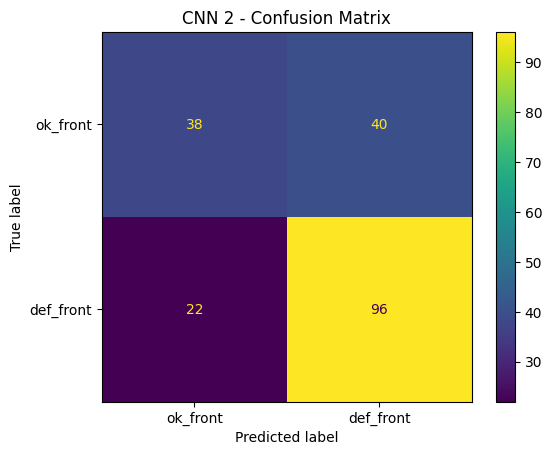

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


# True labels
y_true = np.concatenate([
    labels.numpy().flatten()
    for _, labels in test_dataset
])

# CNN 2 predictions
y_prob_cnn2 = cnn2.predict(test_dataset, verbose=0).flatten()
y_pred_cnn2 = (y_prob_cnn2 >= 0.5).astype(int)

# Classification Report
print("CNN 2 Classification Report:\n")

print(
    classification_report(
        y_true,
        y_pred_cnn2,
        target_names=class_names,
        digits=4
    )
)

# Confusion Matrix
cm_cnn2 = confusion_matrix(y_true, y_pred_cnn2)

print("\nCNN 2 Confusion Matrix:")
print(cm_cnn2)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cnn2,
    display_labels=class_names
)

disp.plot()
plt.title("CNN 2 - Confusion Matrix")
plt.show()

In [14]:
cnn3 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),

    data_augmentation,
    tf.keras.layers.Rescaling(1.0 / 255),

    # Block 1
    tf.keras.layers.Conv2D(32, (3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Conv2D(32, (3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.20),

    # Block 2
    tf.keras.layers.Conv2D(64, (3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Conv2D(64, (3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.25),

    # Block 3
    tf.keras.layers.Conv2D(128, (3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Conv2D(128, (3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.30),

    # Block 4
    tf.keras.layers.Conv2D(256, (3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.40),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

cnn3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 618,017 (2.36 MB)

 Trainable params: 616,609 (2.35 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [15]:
cnn3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

callbacks_cnn3 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "cnn3_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history_cnn3 = cnn3.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15,
    callbacks=callbacks_cnn3
)

Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 114s 4s/step - accuracy: 0.7426 - loss: 0.5268 - precision: 0.7708 - recall: 0.8132 - val_accuracy: 0.4000 - val_loss: 2.4350 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 111s 4s/step - accuracy: 0.7723 - loss: 0.4865 - precision: 0.8122 - recall: 0.8077 - val_accuracy: 0.5590 - val_loss: 0.8183 - val_precision: 0.9697 - val_recall: 0.2735
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 109s 4s/step - accuracy: 0.7789 - loss: 0.4533 - precision: 0.8119 - recall: 0.8223 - val_accuracy: 0.6000 - val_loss: 1.9096 - val_precision: 0.6000 - val_recall: 1.0000
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 110s 4s/step - accuracy: 0.7998 - loss: 0.4159 - precision: 0.8321 - recall: 0.8352 - val_accuracy: 0.6000 - val_loss: 1.8782 - val_precision: 0.6000 - val_recall: 1.0000
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 107s 4s/step - accuracy: 0.8306 - loss: 0.3856 - precision: 0.8684 - recall: 0.8462 - val_accuracy: 0.6103 - val_loss:

In [16]:
test_results_cnn3 = cnn3.evaluate(
    test_dataset,
    verbose=1
)

print("\nCNN 3 Test Results:")
print("Loss:", test_results_cnn3[0])
print("Accuracy:", test_results_cnn3[1])
print("Precision:", test_results_cnn3[2])
print("Recall:", test_results_cnn3[3])

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 503ms/step - accuracy: 0.6020 - loss: 0.7954 - precision: 0.9348 - recall: 0.3644   

CNN 3 Test Results:
Loss: 0.7954374551773071
Accuracy: 0.6020408272743225
Precision: 0.9347826242446899
Recall: 0.3644067943096161


CNN 3 Classification Report:

              precision    recall  f1-score   support

    ok_front     0.5000    0.9615    0.6579        78
   def_front     0.9348    0.3644    0.5244       118

    accuracy                         0.6020       196
   macro avg     0.7174    0.6630    0.5911       196
weighted avg     0.7618    0.6020    0.5775       196


CNN 3 Confusion Matrix:
[[75  3]
 [75 43]]


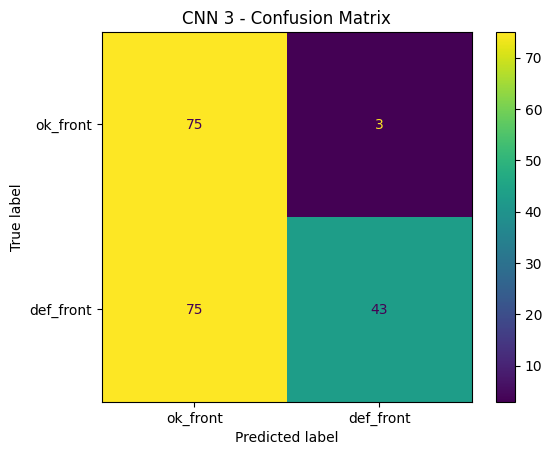

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


# True labels
y_true = np.concatenate([
    labels.numpy().flatten()
    for _, labels in test_dataset
])

# CNN 3 predictions
y_prob_cnn3 = cnn3.predict(test_dataset, verbose=0).flatten()
y_pred_cnn3 = (y_prob_cnn3 >= 0.5).astype(int)

# Classification Report
print("CNN 3 Classification Report:\n")

print(
    classification_report(
        y_true,
        y_pred_cnn3,
        target_names=class_names,
        digits=4
    )
)

# Confusion Matrix
cm_cnn3 = confusion_matrix(y_true, y_pred_cnn3)

print("\nCNN 3 Confusion Matrix:")
print(cm_cnn3)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cnn3,
    display_labels=class_names
)

disp.plot()
plt.title("CNN 3 - Confusion Matrix")
plt.show()

In [18]:
# Predictions from all 3 CNN models

pred_cnn1 = cnn1.predict(test_dataset, verbose=0).flatten()
pred_cnn2 = cnn2.predict(test_dataset, verbose=0).flatten()
pred_cnn3 = cnn3.predict(test_dataset, verbose=0).flatten()

print("CNN 1 predictions:", pred_cnn1.shape)
print("CNN 2 predictions:", pred_cnn2.shape)
print("CNN 3 predictions:", pred_cnn3.shape)

CNN 1 predictions: (196,)
CNN 2 predictions: (196,)
CNN 3 predictions: (196,)


In [19]:
# Convert probabilities to class predictions
pred_class_cnn1 = (pred_cnn1 >= 0.5).astype(int)
pred_class_cnn2 = (pred_cnn2 >= 0.5).astype(int)
pred_class_cnn3 = (pred_cnn3 >= 0.5).astype(int)

# Majority voting
votes = np.vstack([
    pred_class_cnn1,
    pred_class_cnn2,
    pred_class_cnn3
])

ensemble_majority = (np.sum(votes, axis=0) >= 2).astype(int)

print("Majority Voting completed!")
print("Predictions:", ensemble_majority.shape)

Majority Voting completed!
Predictions: (196,)


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

majority_accuracy = accuracy_score(y_true, ensemble_majority)
majority_precision = precision_score(y_true, ensemble_majority)
majority_recall = recall_score(y_true, ensemble_majority)
majority_f1 = f1_score(y_true, ensemble_majority)

print("Majority Voting Results")
print("-----------------------")
print("Accuracy :", majority_accuracy)
print("Precision:", majority_precision)
print("Recall   :", majority_recall)
print("F1-Score :", majority_f1)

Majority Voting Results
-----------------------
Accuracy : 0.6989795918367347
Precision: 0.743801652892562
Recall   : 0.7627118644067796
F1-Score : 0.7531380753138075


In [21]:
# Soft Voting

ensemble_soft_prob = (
    pred_cnn1 +
    pred_cnn2 +
    pred_cnn3
) / 3

# Convert average probability to class
ensemble_soft = (ensemble_soft_prob >= 0.5).astype(int)

print("Soft Voting completed!")
print("Predictions:", ensemble_soft.shape)

Soft Voting completed!
Predictions: (196,)


In [22]:
soft_accuracy = accuracy_score(y_true, ensemble_soft)
soft_precision = precision_score(y_true, ensemble_soft)
soft_recall = recall_score(y_true, ensemble_soft)
soft_f1 = f1_score(y_true, ensemble_soft)

print("Soft Voting Results")
print("-------------------")
print("Accuracy :", soft_accuracy)
print("Precision:", soft_precision)
print("Recall   :", soft_recall)
print("F1-Score :", soft_f1)

Soft Voting Results
-------------------
Accuracy : 0.7653061224489796
Precision: 0.8333333333333334
Recall   : 0.7627118644067796
F1-Score : 0.7964601769911505


In [23]:
# Calculate metrics for all models and ensembles

models_comparison = []

# CNN 1
models_comparison.append([
    "CNN 1",
    accuracy_score(y_true, y_pred),
    precision_score(y_true, y_pred),
    recall_score(y_true, y_pred),
    f1_score(y_true, y_pred)
])

# CNN 2
models_comparison.append([
    "CNN 2",
    accuracy_score(y_true, y_pred_cnn2),
    precision_score(y_true, y_pred_cnn2),
    recall_score(y_true, y_pred_cnn2),
    f1_score(y_true, y_pred_cnn2)
])

# CNN 3
models_comparison.append([
    "CNN 3",
    accuracy_score(y_true, y_pred_cnn3),
    precision_score(y_true, y_pred_cnn3),
    recall_score(y_true, y_pred_cnn3),
    f1_score(y_true, y_pred_cnn3)
])

# Majority Voting
models_comparison.append([
    "Majority Voting",
    majority_accuracy,
    majority_precision,
    majority_recall,
    majority_f1
])

# Soft Voting
models_comparison.append([
    "Soft Voting",
    soft_accuracy,
    soft_precision,
    soft_recall,
    soft_f1
])

comparison_df = pd.DataFrame(
    models_comparison,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,CNN 1,0.693878,0.745763,0.745763,0.745763
1,CNN 2,0.683673,0.705882,0.813559,0.755906
2,CNN 3,0.602041,0.934783,0.364407,0.524390
3,Majority Voting,0.698980,0.743802,0.762712,0.753138
4,Soft Voting,0.765306,0.833333,0.762712,0.796460


In [24]:
# Model parameters and size

models = {
    "CNN 1": cnn1,
    "CNN 2": cnn2,
    "CNN 3": cnn3
}

model_info = []

for name, model in models.items():
    params = model.count_params()
    
    # Approximate model size for float32 weights
    size_mb = (params * 4) / (1024 ** 2)
    
    model_info.append([
        name,
        params,
        size_mb
    ])

model_info_df = pd.DataFrame(
    model_info,
    columns=[
        "Model",
        "Parameters",
        "Approx. Size (MB)"
    ]
)

model_info_df

,Model,Parameters,Approx. Size (MB)
0,CNN 1,101569,0.387455
1,CNN 2,102465,0.390873
2,CNN 3,618017,2.357548


In [25]:
import time

# Take one batch from test dataset
sample_images, _ = next(iter(test_dataset))

benchmark_results = []

for name, model in models.items():

    # Warm-up prediction
    model.predict(sample_images, verbose=0)

    # Measure prediction time
    start_time = time.perf_counter()

    for _ in range(10):
        model.predict(sample_images, verbose=0)

    end_time = time.perf_counter()

    total_time = end_time - start_time

    # Average time for one batch
    avg_batch_time = total_time / 10

    # Average time per image
    avg_image_latency = avg_batch_time / sample_images.shape[0]

    # Throughput
    throughput = sample_images.shape[0] / avg_batch_time

    benchmark_results.append([
        name,
        avg_image_latency * 1000,
        throughput
    ])

benchmark_df = pd.DataFrame(
    benchmark_results,
    columns=[
        "Model",
        "Avg Latency per Image (ms)",
        "Throughput (images/sec)"
    ]
)

benchmark_df

,Model,Avg Latency per Image (ms),Throughput (images/sec)
0,CNN 1,5.681545,176.008453
1,CNN 2,8.746435,114.332292
2,CNN 3,18.474105,54.129820


In [26]:
from tensorflow.keras import layers

# Rotation test dataset
rotation_layer = layers.RandomRotation(0.15)

rotated_images = []
rotated_labels = []

for images, labels in test_dataset:
    aug_images = rotation_layer(images, training=True)
    rotated_images.append(aug_images)
    rotated_labels.append(labels)

rotated_images = tf.concat(rotated_images, axis=0)
rotated_labels = tf.concat(rotated_labels, axis=0)

print("Rotated test images:", rotated_images.shape)
print("Rotated test labels:", rotated_labels.shape)

Rotated test images: (196, 224, 224, 3)
Rotated test labels: (196, 1)


In [27]:
# Evaluate all 3 CNNs on rotated test images

rotated_results = []

for name, model in models.items():
    probabilities = model.predict(rotated_images, verbose=0).flatten()
    predictions = (probabilities >= 0.5).astype(int)

    accuracy = accuracy_score(rotated_labels.numpy(), predictions)

    rotated_results.append([
        name,
        accuracy
    ])

rotated_df = pd.DataFrame(
    rotated_results,
    columns=[
        "Model",
        "Rotated Test Accuracy"
    ]
)

rotated_df

,Model,Rotated Test Accuracy
0,CNN 1,0.653061
1,CNN 2,0.658163
2,CNN 3,0.607143


In [29]:
# Create blurred and noisy versions of test images

# Simple Gaussian blur kernel
gaussian_kernel = tf.constant([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=tf.float32)

gaussian_kernel = gaussian_kernel / tf.reduce_sum(gaussian_kernel)

# Convert to 4D kernel for depthwise convolution
gaussian_kernel = tf.reshape(gaussian_kernel, [3, 3, 1, 1])

blurred_images = []
noisy_images = []
robust_labels = []

for images, labels in test_dataset:

    # Normalize kernel for RGB channels
    kernel_rgb = tf.tile(gaussian_kernel, [1, 1, 3, 1])

    # Blur images
    blur_imgs = tf.nn.depthwise_conv2d(
        images,
        kernel_rgb,
        strides=[1, 1, 1, 1],
        padding="SAME"
    )

    # Add Gaussian noise
    noise = tf.random.normal(
        shape=tf.shape(images),
        mean=0.0,
        stddev=15.0
    )

    noisy_imgs = tf.clip_by_value(
        images + noise,
        0,
        255
    )

    blurred_images.append(blur_imgs)
    noisy_images.append(noisy_imgs)
    robust_labels.append(labels)

blurred_images = tf.concat(blurred_images, axis=0)
noisy_images = tf.concat(noisy_images, axis=0)
robust_labels = tf.concat(robust_labels, axis=0)

print("Blurred images:", blurred_images.shape)
print("Noisy images:", noisy_images.shape)
print("Labels:", robust_labels.shape)

Blurred images: (196, 224, 224, 3)
Noisy images: (196, 224, 224, 3)
Labels: (196, 1)


In [30]:
# Evaluate CNN models on blurred and noisy images

robustness_results = []

for name, model in models.items():

    # Blurred images
    blur_prob = model.predict(blurred_images, verbose=0).flatten()
    blur_pred = (blur_prob >= 0.5).astype(int)
    blur_accuracy = accuracy_score(
        robust_labels.numpy(),
        blur_pred
    )

    # Noisy images
    noise_prob = model.predict(noisy_images, verbose=0).flatten()
    noise_pred = (noise_prob >= 0.5).astype(int)
    noise_accuracy = accuracy_score(
        robust_labels.numpy(),
        noise_pred
    )

    robustness_results.append([
        name,
        blur_accuracy,
        noise_accuracy
    ])

robustness_df = pd.DataFrame(
    robustness_results,
    columns=[
        "Model",
        "Blur Accuracy",
        "Noise Accuracy"
    ]
)

robustness_df

,Model,Blur Accuracy,Noise Accuracy
0,CNN 1,0.520408,0.637755
1,CNN 2,0.647959,0.760204
2,CNN 3,0.637755,0.520408


In [31]:
# Model disagreement analysis

prediction_matrix = np.vstack([
    pred_class_cnn1,
    pred_class_cnn2,
    pred_class_cnn3
])

# Number of models predicting class 1
vote_count = np.sum(prediction_matrix, axis=0)

# Images where all 3 models agree
all_agree = np.sum(
    (pred_class_cnn1 == pred_class_cnn2) &
    (pred_class_cnn2 == pred_class_cnn3)
)

# Images where models disagree
disagreement_count = len(y_true) - all_agree

print("Total test images :", len(y_true))
print("All models agree  :", all_agree)
print("Models disagree   :", disagreement_count)
print(
    "Disagreement rate  :",
    disagreement_count / len(y_true)
)

# Show vote distribution
print("\nVote Distribution:")
print("0 models predict defect:", np.sum(vote_count == 0))
print("1 model predicts defect :", np.sum(vote_count == 1))
print("2 models predict defect :", np.sum(vote_count == 2))
print("3 models predict defect :", np.sum(vote_count == 3))

Total test images : 196
All models agree  : 93
Models disagree   : 103
Disagreement rate  : 0.5255102040816326

Vote Distribution:
0 models predict defect: 55
1 model predicts defect : 20
2 models predict defect : 83
3 models predict defect : 38


In [32]:
# Confidence analysis

confidence_cnn1 = np.maximum(
    pred_cnn1,
    1 - pred_cnn1
)

confidence_cnn2 = np.maximum(
    pred_cnn2,
    1 - pred_cnn2
)

confidence_cnn3 = np.maximum(
    pred_cnn3,
    1 - pred_cnn3
)

confidence_soft = np.maximum(
    ensemble_soft_prob,
    1 - ensemble_soft_prob
)

print("Average Confidence")
print("------------------")
print("CNN 1        :", np.mean(confidence_cnn1))
print("CNN 2        :", np.mean(confidence_cnn2))
print("CNN 3        :", np.mean(confidence_cnn3))
print("Soft Voting  :", np.mean(confidence_soft))

Average Confidence
------------------
CNN 1        : 0.68547523
CNN 2        : 0.78520226
CNN 3        : 0.76987046
Soft Voting  : 0.68292385


In [33]:
# Final production comparison table

final_comparison = comparison_df.copy()

# Add parameter and size information
final_comparison = final_comparison.merge(
    model_info_df,
    on="Model",
    how="left"
)

# Add benchmark information
final_comparison = final_comparison.merge(
    benchmark_df,
    on="Model",
    how="left"
)

final_comparison

,Model,Accuracy,Precision,Recall,F1-Score,Parameters,Approx. Size (MB),Avg Latency per Image (ms),Throughput (images/sec)
0,CNN 1,0.693878,0.745763,0.745763,0.745763,101569.0,0.387455,5.681545,176.008453
1,CNN 2,0.683673,0.705882,0.813559,0.755906,102465.0,0.390873,8.746435,114.332292
2,CNN 3,0.602041,0.934783,0.364407,0.524390,618017.0,2.357548,18.474105,54.129820
3,Majority Voting,0.698980,0.743802,0.762712,0.753138,NaN,NaN,NaN,NaN
4,Soft Voting,0.765306,0.833333,0.762712,0.796460,NaN,NaN,NaN,NaN


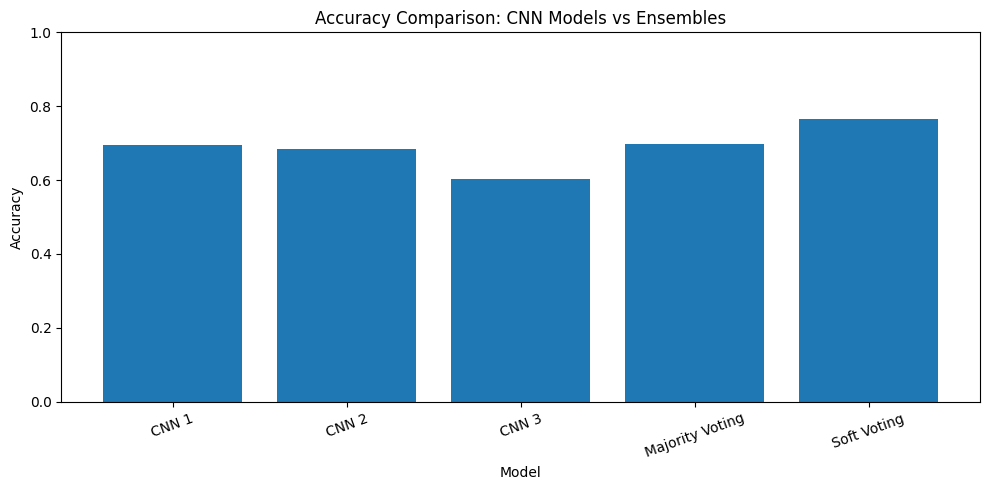

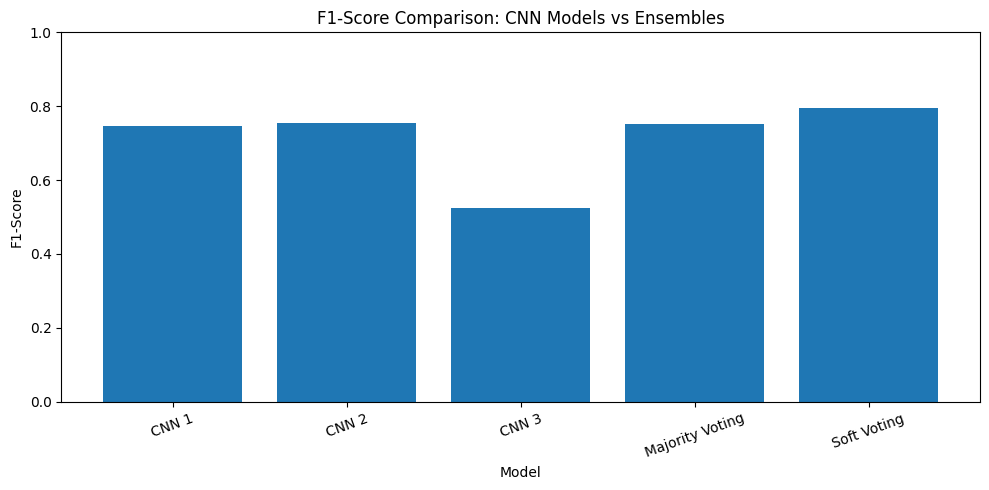

In [34]:
# Final Performance Graphs

import matplotlib.pyplot as plt

# Accuracy Comparison
plt.figure(figsize=(10, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Accuracy Comparison: CNN Models vs Ensembles")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# F1-Score Comparison
plt.figure(figsize=(10, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["F1-Score"]
)

plt.ylim(0, 1)
plt.ylabel("F1-Score")
plt.xlabel("Model")
plt.title("F1-Score Comparison: CNN Models vs Ensembles")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [35]:
# Identify the best performing model

best_model_row = comparison_df.loc[
    comparison_df["F1-Score"].idxmax()
]

print("BEST MODEL")
print("----------")
print("Model     :", best_model_row["Model"])
print("Accuracy  :", best_model_row["Accuracy"])
print("Precision :", best_model_row["Precision"])
print("Recall    :", best_model_row["Recall"])
print("F1-Score  :", best_model_row["F1-Score"])

BEST MODEL
----------
Model     : Soft Voting
Accuracy  : 0.7653061224489796
Precision : 0.8333333333333334
Recall    : 0.7627118644067796
F1-Score  : 0.7964601769911505


In [36]:
# Production Recommendation

best_model = comparison_df.loc[
    comparison_df["F1-Score"].idxmax(),
    "Model"
]

best_f1 = comparison_df.loc[
    comparison_df["F1-Score"].idxmax(),
    "F1-Score"
]

best_accuracy = comparison_df.loc[
    comparison_df["F1-Score"].idxmax(),
    "Accuracy"
]

print("PRODUCTION RECOMMENDATION")
print("=========================")
print(f"Recommended Model : {best_model}")
print(f"Accuracy          : {best_accuracy:.4f}")
print(f"F1-Score          : {best_f1:.4f}")

print("\nReason:")
print("The model with the highest F1-score is selected as the primary")
print("candidate because both precision and recall are important for")
print("manufacturing defect classification.")

print("\nNote:")
print("Final deployment should also consider latency, throughput,")
print("model size and robustness before production deployment.")

PRODUCTION RECOMMENDATION
Recommended Model : Soft Voting
Accuracy          : 0.7653
F1-Score          : 0.7965

Reason:
The model with the highest F1-score is selected as the primary
candidate because both precision and recall are important for
manufacturing defect classification.

Note:
Final deployment should also consider latency, throughput,
model size and robustness before production deployment.


In [37]:
# Production Recommendation

best_model = comparison_df.loc[
    comparison_df["F1-Score"].idxmax(),
    "Model"
]

best_f1 = comparison_df.loc[
    comparison_df["F1-Score"].idxmax(),
    "F1-Score"
]

best_accuracy = comparison_df.loc[
    comparison_df["F1-Score"].idxmax(),
    "Accuracy"
]

print("PRODUCTION RECOMMENDATION")
print("=========================")
print(f"Recommended Model : {best_model}")
print(f"Accuracy          : {best_accuracy:.4f}")
print(f"F1-Score          : {best_f1:.4f}")

print("\nReason:")
print("The model with the highest F1-score is selected as the primary")
print("candidate because both precision and recall are important for")
print("manufacturing defect classification.")

print("\nNote:")
print("Final deployment should also consider latency, throughput,")
print("model size and robustness before production deployment.")

PRODUCTION RECOMMENDATION
Recommended Model : Soft Voting
Accuracy          : 0.7653
F1-Score          : 0.7965

Reason:
The model with the highest F1-score is selected as the primary
candidate because both precision and recall are important for
manufacturing defect classification.

Note:
Final deployment should also consider latency, throughput,
model size and robustness before production deployment.
